# Granite 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.decompositions import get_components_brute_force, get_regional_decompositions
from granite.plots import partial_dependence_plot, plot_legend

from matplotlib import rc
rc('font', **{'size':15})

/home//anaconda3/envs/GRANITE/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup
We must set a `Features` object to let the code know which features are numerical, categorical, integers etc. This will
help computing functional decompositions more efficiently (e.g. cat features have finite cardinality), and will also help
determine splits when fitting a decision tree.

In [2]:
def generate_problem(N, seed):
    # Generate input
    np.random.seed(seed)
    X_1 = np.random.normal(0, 1, size=(N,))
    X_2 = 2 * np.random.randint(0, 2, size=(N,)) - 1
    X_3 = 2 * np.random.randint(0, 2, size=(N,)) - 1
    X_4 = X_3 + 0.5 * np.random.normal(0, 1, size=(N,))

    # Model to explain
    def f(X):
        return 3 * X[:, 0] * X[:, 1] + X[:, 2] + 2 * X[:, 3]
    return np.column_stack((X_1, X_2, X_3, X_4)), f

# We generate the data and models. The data X is stored in a (N, d) numpy array
X, f = generate_problem(2000, 42)
features = Features(
                X, 
                names=[f"X{i}" for i in range(1, 5)], 
                types=["num", "num_int", "num_int", "num"]
            )
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | X1                 | num                | inf        | [0]              |
| 1 | X2                 | num_int            | 2          | [1]              |
| 2 | X3                 | num_int            | 2          | [2]              |
| 3 | X4                 | num                | inf        | [3]              |
-------------------------------------------------------------------------------



The `get_components_brute_force` takes as input a model `f`, evaluation points `X` at which the functional decomposition is evaluated, reference points `X` used for masking
(does not need to be the whole dataset), a `Features` object, and a flag `anchored` to let it know whether to return the anchored decomposition or the marginal one.
We compute the anchored decomposition and store it in matrices $H^{k}$ such that

$$ H^{k}_{ij} = f(x^{(i)}_k, x^{(j)}_{-k}) - f(x^{(j)})$$

These matrices are more efficient to compute than their Mobieus inverse

$$ R^{k}_{ij} = f(x^{(i)}_k, x^{(j)}_{-k})$$

since they are sparser (their components which are know to be zero will not need to be computed).

In [3]:
# Compute the Anchored Decomposition. Averaging it column-wise leads to the marginal decomposition.
decomposition = get_components_brute_force(f, X, X, features, anchored=True)
display(decomposition.keys())
display(decomposition[()].shape) # The null set is the model evaluation h(x^(i)) at all datapoints
display(decomposition[(0,)].shape)  # The component (0,) is a NxN matric whose ij term is h_{0,x^(j)}(x^(i))

dict_keys([(), (0,), (1,), (2,), (3,)])

(2000,)

(2000, 2000)

## Pure-vs-Full Marginal effects for $X_1$
Thin lines are ICE curves and the thick line is the PDP

$$ f^{PDP}(x_k) = \mathbb{E}_{z\sim D}[f(x_k, z_{-k})].$$

Both of these effects are marginal (not conditional) since we replace feature $X_1$ with other values
from the dataset, irrespective of possible correlations. Disagreements among these curves are therefore indicative of strong **feature interactions** involving feature $X_1$.

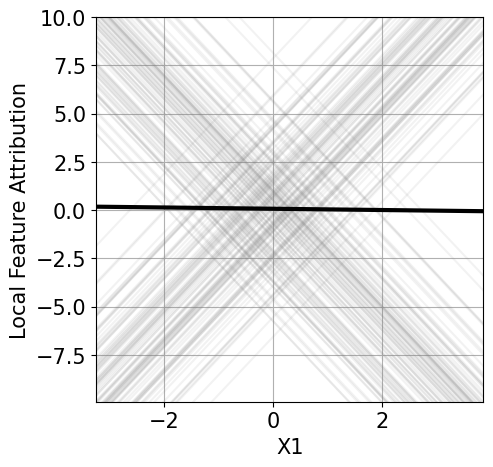

In [4]:
partial_dependence_plot(decomposition, X, features, idxs=[0], figsize=(5, 5))

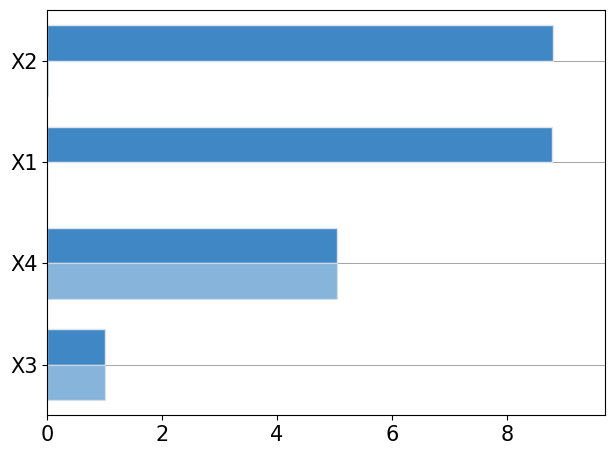

In [5]:
from granite.experiments import get_closed_total_sobol
from granite.plots import bar, INTERACTION_PALETTE

H_tensor = np.stack([decomposition[(i,)] for i in range(4)], axis=-1)
closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
bar([total_sobol, closed_sobol], features.names(), color=INTERACTION_PALETTE[0])
plt.savefig(os.path.join("..", "figures", "toy_marginal_pure_full_global_variance.pdf"), bbox_inches="tight")

We reduce disagreements by fitting a decision tree that minimizes the difference between the pure and full marginal effects of $X_1$. Given the
$N\times N$ matrices $H^k$, it is possible to effciently compute the pure-full disagreements by comparing row-wise to column-wise averages.

In [6]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_loss_fn(
                                        decomposition=decomposition,
                                        U=[(0,), (1,), (2,), (3,)]
                                )

# We want to split on the remaining features so we call the .select method
# `branching_per_node>1` finds better solutions than greedy since multiple splits can be attempted as a given node
tree = FDTree(features.select([1, 2, 3]), max_depth=2, save_losses=True, branching_per_node=3)
# We pass U=[(0,)] in order to only minimize the pure-full effect of feature 0
tree.fit(X[:, [1, 2, 3]], loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)


Loss 1.0000
Samples 2000
If X2 ≤ -1.0000:
|   Loss 0.0000
|   Samples 1011
|   Region 0
else:
|   Loss 0.0000
|   Samples 989
|   Region 1
Final Loss 0.0000


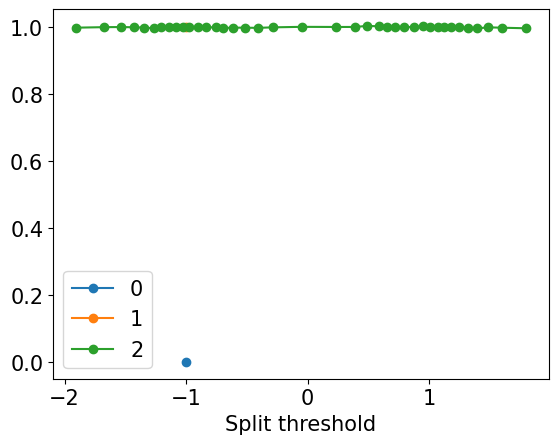

In [7]:
# Plot the loss function as a function of split candidate
plt.figure()
for i in range(3):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i)
plt.xlabel("Split threshold")
plt.legend()

In [8]:
# Use the tree to compute regional decompositions
regions = tree.predict(X[:, [1, 2, 3]])
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
# TODO this does not yield the intended result, my code that generates rules does not
# work properly for feature X_2\in {-1, 1}
print(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
regional_backgrounds = [[]] * n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]


[1 0 1 0 0 1 0 1 1 0]
{0: 'X2<=-1.00', 1: 'X2>-1.00'}


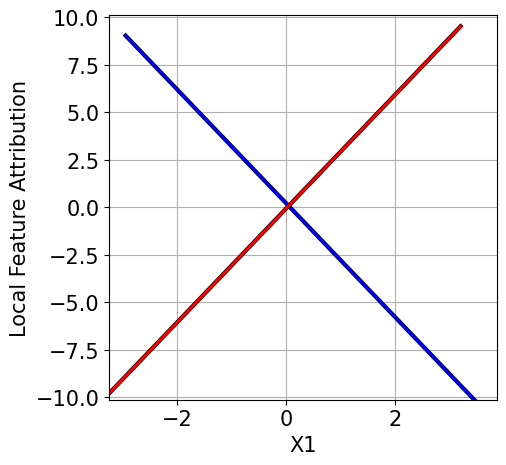

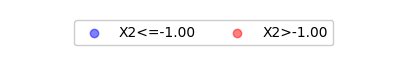

In [9]:
partial_dependence_plot(regional_decompositions, regional_backgrounds, features, idxs=[0], figsize=(5, 5), centered=True)
plot_legend(rules, ncol=2)

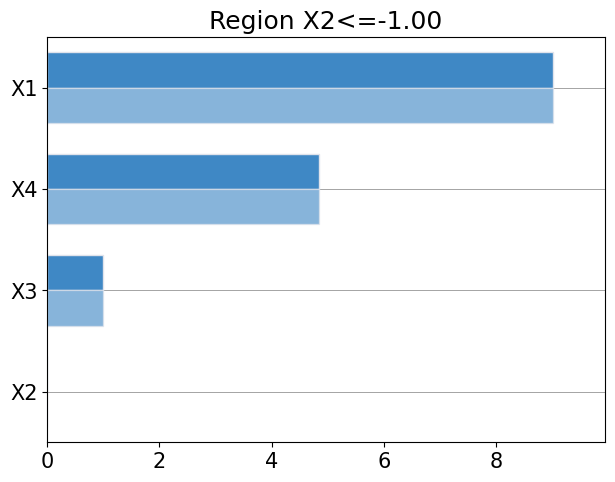

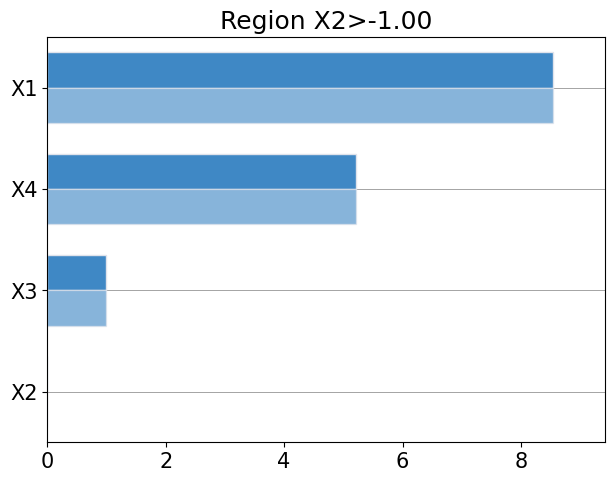

In [10]:
for r in range(tree.n_regions):
    H_tensor = np.stack([regional_decompositions[r][(i,)] for i in range(4)], axis=-1)
    closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
    bar([total_sobol, closed_sobol], features.names(), color=INTERACTION_PALETTE[0])
    plt.title(f"Region {rules[r]}")
    plt.savefig(os.path.join("..", "figures", f"toy_marginal_pure_full_global_variance_region_{r}.pdf"), bbox_inches="tight")

Here the regional ICE (thin lines) and PDP (thick lines) are perfectly superposed.

## Marginal-vs-Conditional Effect for $X_4$

The Conditional Effects are easier to compute using the matrix $R^k_{ij} = f(x^{(i)}_k, x^{(j)}_{-k})$ instead of the $H^k$ matrices.
They also rely on bins : masking will only be done using datapoints that land in the same bin as the evaluation point.

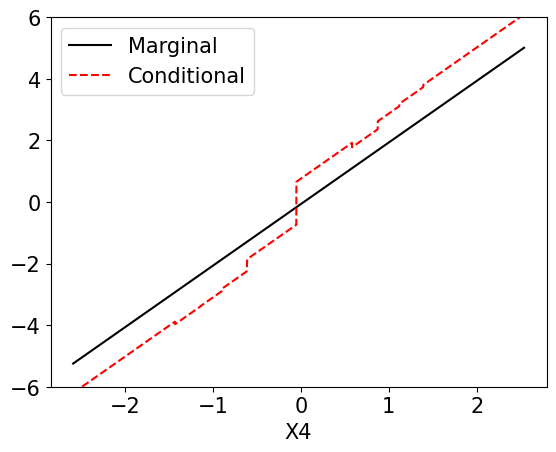

In [11]:
from granite.experiments import get_marginal_conditional_effects
from granite.utils import create_bins_for_data, decomposition_to_R

bins, binned_features = create_bins_for_data(
    X, cat_feature_indices=[], n_bins_numerical=10
)
R = decomposition_to_R(decomposition)

marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_features[3], R[(3,)])
argsort_x_i = np.argsort(X[:, 3])
plt.plot(X[argsort_x_i, 3], marginal_effect[argsort_x_i], 'k-', label="Marginal")
plt.plot(X[argsort_x_i, 3], conditional_effect[argsort_x_i], 'r--', label="Conditional")
plt.xlabel("X4")
plt.ylim(-6, 6)
plt.legend()

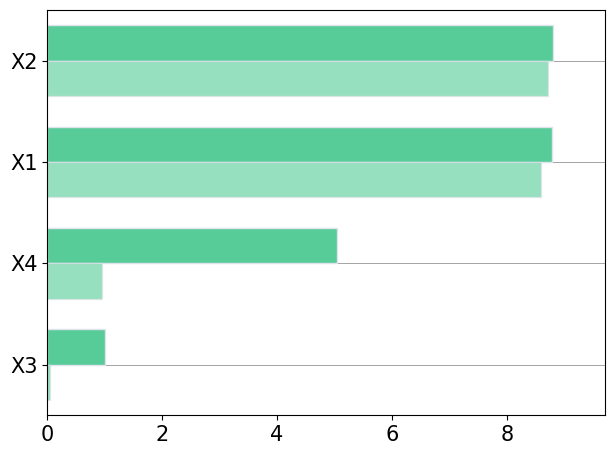

In [12]:
from granite.experiments import get_marginal_conditional_sobol
from granite.utils import create_bins_for_data_partition_tree, decomposition_to_R
from granite.plots import CORRELATION_PALETTE

bins, binned_features = create_bins_for_data_partition_tree(
    X, cat_feature_indices=[], max_leaf_nodes=10
)
n_features = len(features)
R = decomposition_to_R(decomposition)
marginal_sobol = np.zeros(n_features)
cond_sobol = np.zeros(n_features)
for i in range(n_features):
    marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(binned_features[i], R[(i,)])

bar([marginal_sobol, cond_sobol], features.names(), color=CORRELATION_PALETTE[0])
plt.savefig(os.path.join("..", "figures", "toy_marginal_cond_full_global_variance.pdf"), bbox_inches="tight")

In [13]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_vs_conditional_pure_loss_fn

loss_fn = get_marginal_vs_conditional_pure_loss_fn(
                                        decomposition=decomposition,
                                        U=[(3,)],
                                        binned_features=[binned_features[3]]
)

# We only split along the features that exclude X_4
tree = FDTree(features.select([0, 1, 2]), max_depth=2, save_losses=True, branching_per_node=2, alpha=0.2)
tree.fit(X[:, [0, 1, 2]], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 2000
If X3 ≤ -1.0000:
|   Loss 0.0114
|   Samples 1000
|   Region 0
else:
|   Loss 0.6727
|   Samples 1000
|   Region 1
Final Loss 0.6841


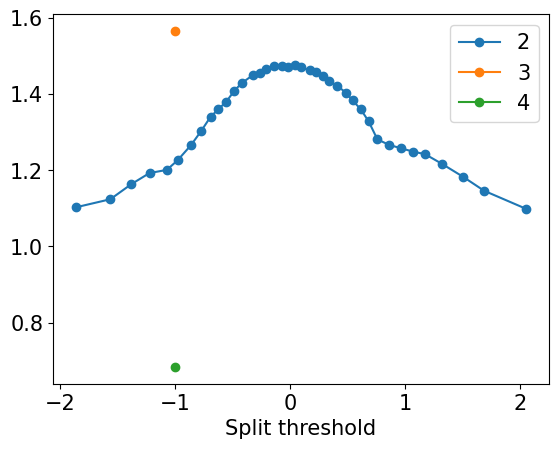

In [14]:
plt.figure()
for i in range(3):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i+2)
plt.xlabel("Split threshold")
plt.legend()

In [15]:
regions = tree.predict(X[:, [0, 1, 2]])
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
regional_backgrounds = [[]] * n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]

[0 0 1 1 1 1 0 1 1 1]
{0: 'X3<=-1.00', 1: 'X3>-1.00'}


In [16]:
# fig, axes = plt.subplots(1, n_regions, figsize=(5*n_regions, 5))
# for r in range(tree.n_regions):
#     R = regional_decompositions[r][(3,)] + regional_decompositions[r][()]
#     X_region = regional_backgrounds[r]
#     marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_features[3][regions==r], R)
#     argsort_x_i = np.argsort(X_region[:, 3])
#     axes[r].plot(X_region[argsort_x_i, 3], marginal_effect[argsort_x_i], 'k-', label="Marginal")
#     axes[r].plot(X_region[argsort_x_i, 3], conditional_effect[argsort_x_i], 'r--', label="Conditional")
#     axes[r].set_ylim(-6, 6)
#     axes[r].set_title(rules[r])
#     axes[r].set_xlabel("X4")
#     axes[r].legend()

In [17]:

R = decomposition_to_R(decomposition)
regional_R = get_regional_decompositions(R, regions, regions, n_regions)
regional_binned_features = [[]] * n_regions
for r in range(n_regions):
    regional_binned_features[r] = [[]] * n_features
    in_region = regions == r
    for i in range(n_features):
        regional_binned_features[r][i] = binned_features[i][in_region]

<Figure size 640x480 with 0 Axes>

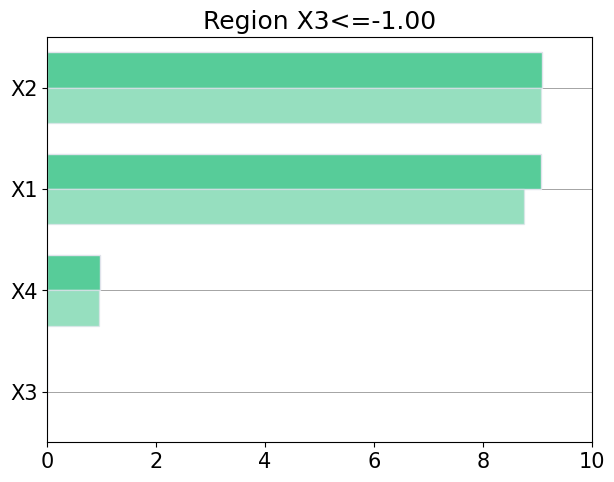

<Figure size 640x480 with 0 Axes>

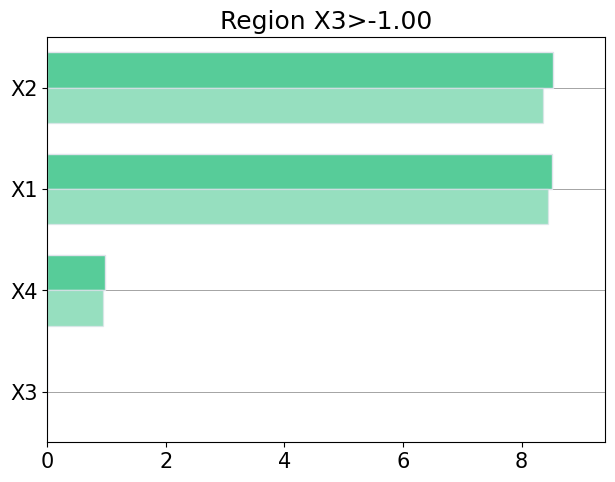

In [18]:
for r in range(tree.n_regions):
    plt.figure()
    marginal_sobol, cond_sobol = np.zeros(n_features), np.zeros(n_features)
    for i in range(n_features):
        marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(regional_binned_features[r][i], regional_R[r][(i,)])
    bar([marginal_sobol, cond_sobol], features.names(), color=CORRELATION_PALETTE[0])
    plt.title(f"Region {rules[r]}")
    plt.savefig(os.path.join("..", "figures", f"toy_marginal_cond_full_global_variance_region_{r}.pdf"), bbox_inches="tight")